In [5]:

import pandas as pd
import json
import glob
from pathlib import Path
from collections import defaultdict
import numpy as np
from datetime import datetime

def load_logs_to_dataframe(log_files):
    """加载所有日志文件到DataFrame"""
    all_data = []
    
    for log_file in log_files:
        with open(log_file, 'r') as f:
            for line in f:
                if line.strip():
                    try:
                        data = json.loads(line.strip())
                        all_data.append(data)
                    except json.JSONDecodeError:
                        print(f"Warning: Invalid JSON in {log_file}: {line}")
                        continue
    
    return pd.DataFrame(all_data)

def create_stage_timeline_df(df):
    """创建每个request_id的阶段时间线DataFrame"""
    
    # 按request_id分组，收集所有事件
    grouped = df.groupby('request_id')
    
    timeline_data = []
    
    for request_id, group in grouped:
        # 为每个request_id创建一行数据
        row_data = {'request_id': request_id}
        
        # 按时间戳排序事件
        sorted_events = group.sort_values('timestamp')
        
        # 记录每个事件的ISO时间戳
        for _, event in sorted_events.iterrows():
            event_name = event['event_name']
            # 只为每个事件创建ISO时间戳列
            row_data[f'{event_name}_timestamp_iso'] = event['timestamp_iso']
        
        timeline_data.append(row_data)
    
    return pd.DataFrame(timeline_data)

def get_df(path):
    # 使用示例
    # 找到所有日志文件
    log_files = glob.glob(path)  # 根据你的实际路径调整

    # 加载数据
    df = load_logs_to_dataframe(log_files)
    print(f"原始数据行数: {len(df)}")
    print(f"唯一request_id数量: {df['request_id'].nunique()}")

    # 过滤掉request_id为0的数据
    df = df[df['request_id'] != 0]
    print(f"过滤后数据行数: {len(df)}")
    print(f"过滤后唯一request_id数量: {df['request_id'].nunique()}")

    # 创建时间线DataFrame
    timeline_df = create_stage_timeline_df(df)
    return timeline_df

def merge_timeline_df(timeline_df_a, timeline_df_b):
    """修复后的合并函数"""
    # 分别过滤两个DataFrame
    df_a_filtered = timeline_df_a[timeline_df_a["request_id"] != "None"]
    df_b_filtered = timeline_df_b[timeline_df_b["request_id"] != "None"]
    
    # 合并A表和B表
    timeline_df = df_a_filtered.merge(df_b_filtered, on="request_id", how="left")
    return timeline_df

timeline_df_a = get_df("/sgl-workspace/sglang/events_log_*")
timeline_df_b = get_df("/sgl-workspace/sglang/events/events_log_*")
timeline_df = merge_timeline_df(timeline_df_a, timeline_df_b)
#把所有时间戳列转换为datetime类型,request_id字段保留为int类型
timeline_df = timeline_df.astype({"request_id": "int"})
timeline_df = timeline_df.apply(lambda x: pd.to_datetime(x) if x.dtype == "object" else x)
timeline_df.dtypes
#把所有时间戳列转换为datetime类型
timeline_df = timeline_df.apply(lambda x: pd.to_datetime(x) if x.dtype == "object" else x)
timeline_df.dtypes
summary_df = pd.DataFrame()

# init_recv_ack_timestamp_iso-init_recv_timestamp_iso
summary_df["request_id"] = timeline_df["request_id"]
# 计算时间差并转换为毫秒
def f(field1, field2,target_field):
    time_diff = timeline_df[field1+"_timestamp_iso"] - timeline_df[field2+"_timestamp_iso"]
    summary_df[target_field] = time_diff.dt.total_seconds() * 1000
    
# f("prefill_bootstrap_done","prefill_add_bootstrap_queue","prefill_boostrap_update_ms")

f("prefill_forward_done","prefill_bootstrap_queue_pop","prefill_forward_ms")
f("prefill_bootstrap_queue_pop","prefill_add_bootstrap_queue","prefill_boostrap_pop_ms")
f("prefill_send_kvcache_done","prefill_start_send_kvcache","prefill_sent_done_ms")
f("prefill_start_send_kvcache","prefill_forward_done","prefill_forward2send_ms")
f("prefill_inflight_queue_done","prefill_send_kvcache_done","prefill_transfer_pop_ms")
# f("prefill_inflight_queue_done","prefill_forward_done","prefill_inflight_ms")
f("decode_transferred_queue_pop","decode_transferred_done","decode_update_ms")

原始数据行数: 52963
唯一request_id数量: 1234
过滤后数据行数: 52515
过滤后唯一request_id数量: 1233
原始数据行数: 5058
唯一request_id数量: 1241
过滤后数据行数: 5016
过滤后唯一request_id数量: 1240


prefill_boostrap_update_ms: Mean=-77.05ms, Median=-62.73ms, Std=85.26ms
prefill_boostrap_pop_ms: Mean=845.17ms, Median=558.89ms, Std=943.29ms
prefill_sent_done_ms: Mean=0.36ms, Median=0.30ms, Std=0.34ms
prefill_forward2send_ms: Mean=3.68ms, Median=3.18ms, Std=4.58ms
prefill_transfer_pop_ms: Mean=137.24ms, Median=189.43ms, Std=80.99ms
decode_update_ms: Mean=1.75ms, Median=1.71ms, Std=1.04ms


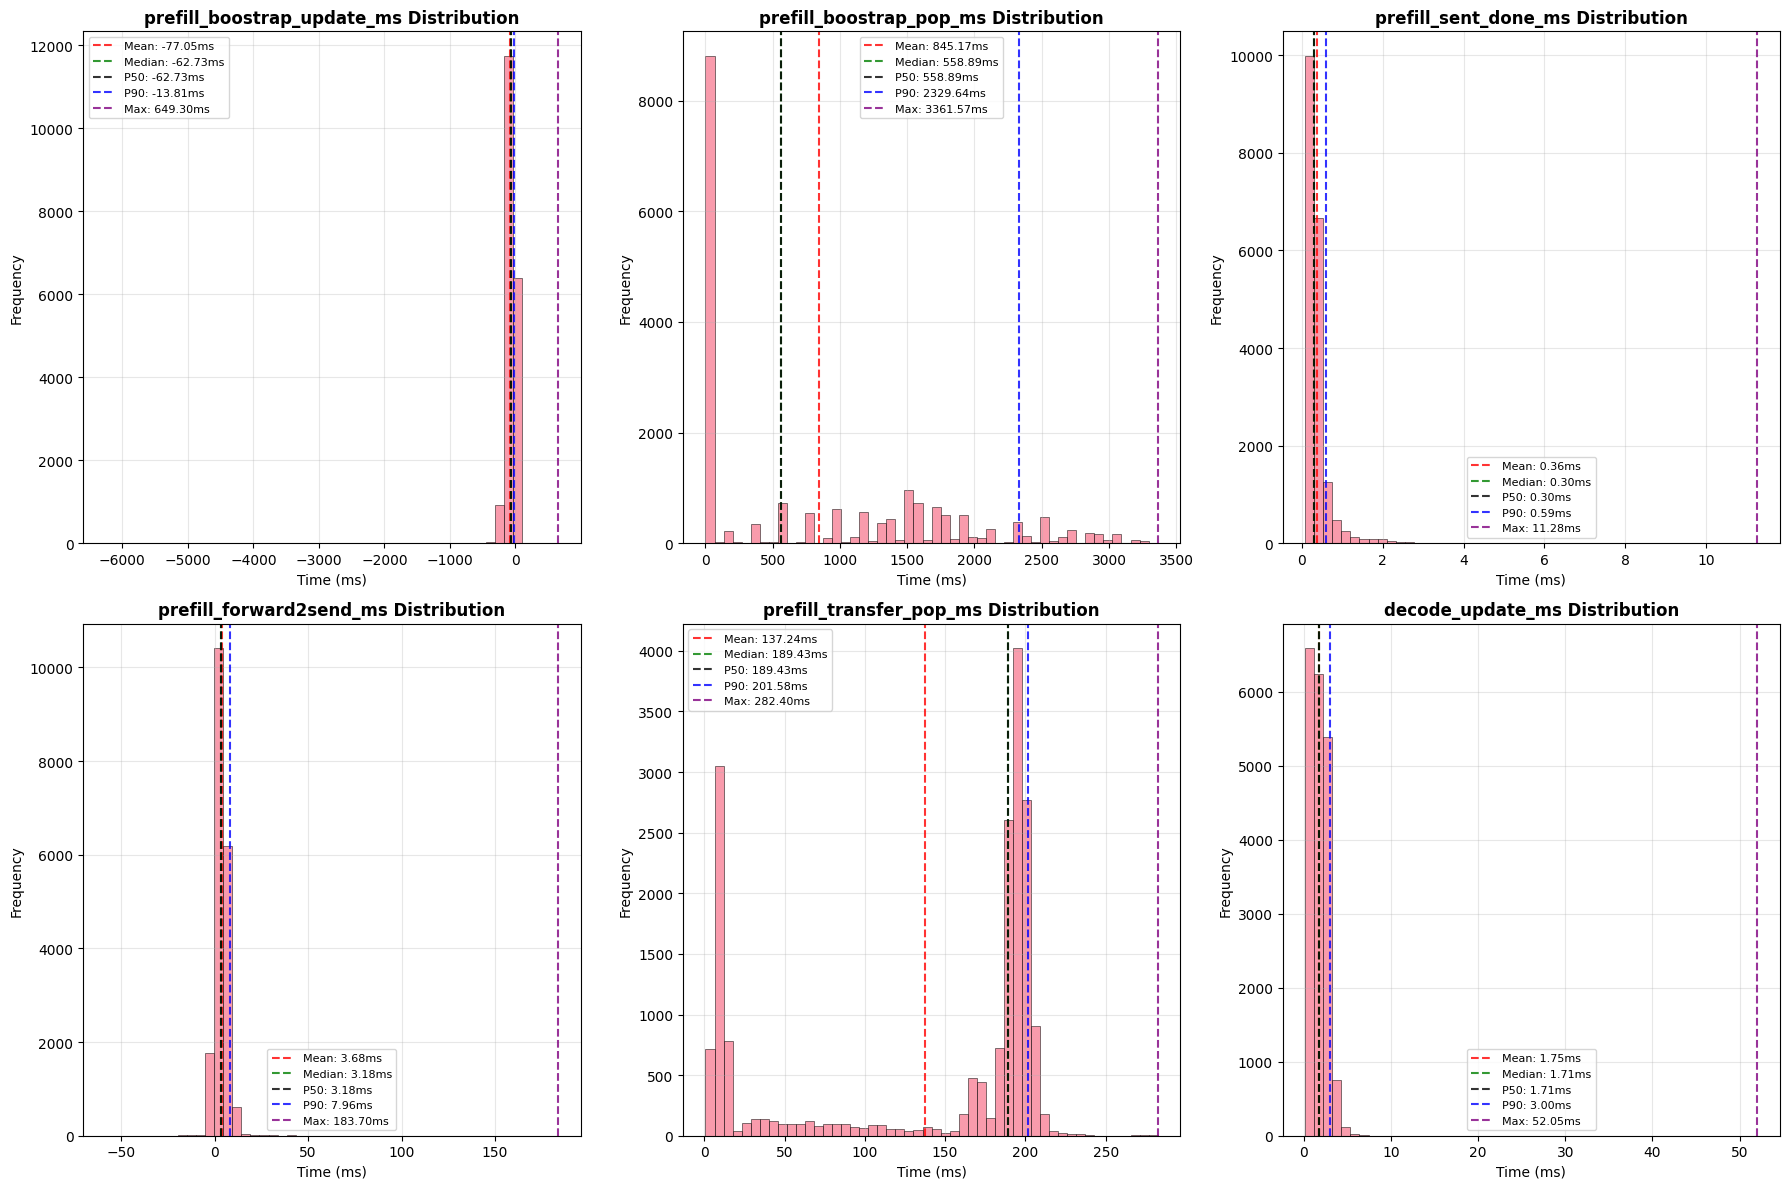

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图样式
plt.style.use('default')
sns.set_palette("husl")

# 要绘制的列
columns_to_plot = summary_df.columns.tolist()[1:]

# 创建子图
fig, axes = plt.subplots(2, len(columns_to_plot)//2, figsize=(18, 12))
axes = axes.flatten()

# 为每个列绘制直方图
for i, col in enumerate(columns_to_plot):
    if col in summary_df.columns:
        # 过滤掉NaN值
        data = summary_df[col].dropna()
        
        # 绘制直方图
        axes[i].hist(data, bins=50, alpha=0.7, edgecolor='black', linewidth=0.5)
        axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Time (ms)', fontsize=10)
        axes[i].set_ylabel('Frequency', fontsize=10)
        axes[i].grid(True, alpha=0.3)
        
        # 添加统计信息
        mean_val = data.mean()
        median_val = data.median()
        axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.2f}ms')
        axes[i].axvline(median_val, color='green', linestyle='--', alpha=0.8, label=f'Median: {median_val:.2f}ms')
        axes[i].axvline(data.quantile(0.5), color='black', linestyle='--', alpha=0.8, label=f'P50: {data.quantile(0.5):.2f}ms')
        axes[i].axvline(data.quantile(0.9), color='blue', linestyle='--', alpha=0.8, label=f'P90: {data.quantile(0.9):.2f}ms')
        axes[i].axvline(data.max(), color='purple', linestyle='--', alpha=0.8, label=f'Max: {data.max():.2f}ms')
        axes[i].legend(fontsize=8)
        
        print(f"{col}: Mean={mean_val:.2f}ms, Median={median_val:.2f}ms, Std={data.std():.2f}ms")

plt.tight_layout()
plt.show()

prefill_forward_ms: Mean=114529.53ms, Median=144085.55ms, Std=61745.93ms
prefill_boostrap_pop_ms: Mean=104345.78ms, Median=71431.47ms, Std=106387.59ms
prefill_sent_done_ms: Mean=1.10ms, Median=0.26ms, Std=3.30ms
prefill_forward2send_ms: Mean=12.54ms, Median=11.14ms, Std=10.28ms
prefill_transfer_pop_ms: Mean=239.60ms, Median=254.96ms, Std=152.96ms
decode_update_ms: Mean=40.34ms, Median=6.02ms, Std=558.26ms


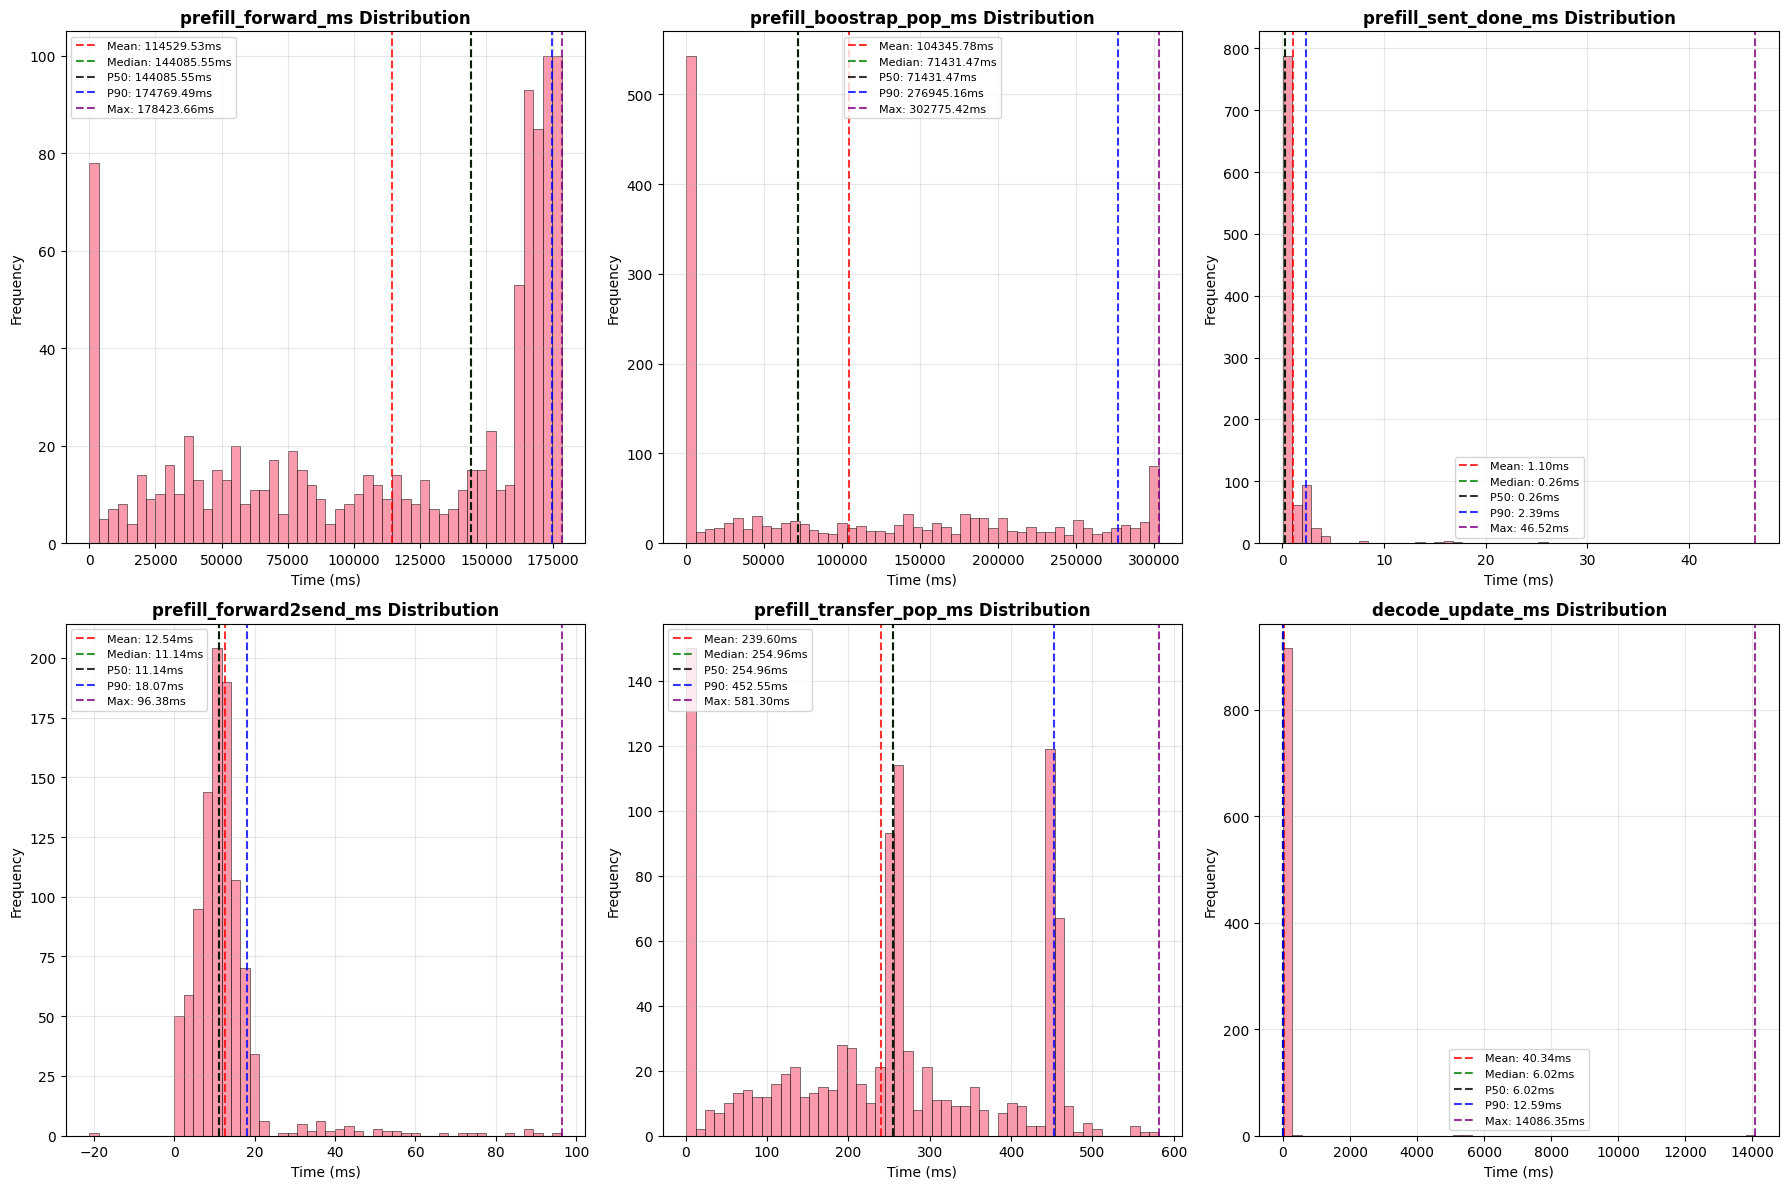

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图样式
plt.style.use('default')
sns.set_palette("husl")

# 要绘制的列
columns_to_plot = summary_df.columns.tolist()[1:]

# 创建子图
fig, axes = plt.subplots(2, len(columns_to_plot)//2, figsize=(18, 12))
axes = axes.flatten()

# 为每个列绘制直方图
for i, col in enumerate(columns_to_plot):
    if col in summary_df.columns:
        # 过滤掉NaN值
        data = summary_df[col].dropna()
        
        # 绘制直方图
        axes[i].hist(data, bins=50, alpha=0.7, edgecolor='black', linewidth=0.5)
        axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Time (ms)', fontsize=10)
        axes[i].set_ylabel('Frequency', fontsize=10)
        axes[i].grid(True, alpha=0.3)
        
        # 添加统计信息
        mean_val = data.mean()
        median_val = data.median()
        axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.2f}ms')
        axes[i].axvline(median_val, color='green', linestyle='--', alpha=0.8, label=f'Median: {median_val:.2f}ms')
        axes[i].axvline(data.quantile(0.5), color='black', linestyle='--', alpha=0.8, label=f'P50: {data.quantile(0.5):.2f}ms')
        axes[i].axvline(data.quantile(0.9), color='blue', linestyle='--', alpha=0.8, label=f'P90: {data.quantile(0.9):.2f}ms')
        axes[i].axvline(data.max(), color='purple', linestyle='--', alpha=0.8, label=f'Max: {data.max():.2f}ms')
        axes[i].legend(fontsize=8)
        
        print(f"{col}: Mean={mean_val:.2f}ms, Median={median_val:.2f}ms, Std={data.std():.2f}ms")

plt.tight_layout()
plt.show()

prefill_forward_ms: Mean=51646.90ms, Median=47338.34ms, Std=34479.20ms
prefill_boostrap_pop_ms: Mean=12.67ms, Median=0.70ms, Std=66.45ms
prefill_sent_done_ms: Mean=0.89ms, Median=0.37ms, Std=2.19ms
prefill_forward2send_ms: Mean=11.37ms, Median=11.50ms, Std=7.32ms
prefill_transfer_pop_ms: Mean=249.90ms, Median=255.68ms, Std=146.68ms
decode_update_ms: Mean=6.88ms, Median=6.48ms, Std=4.15ms


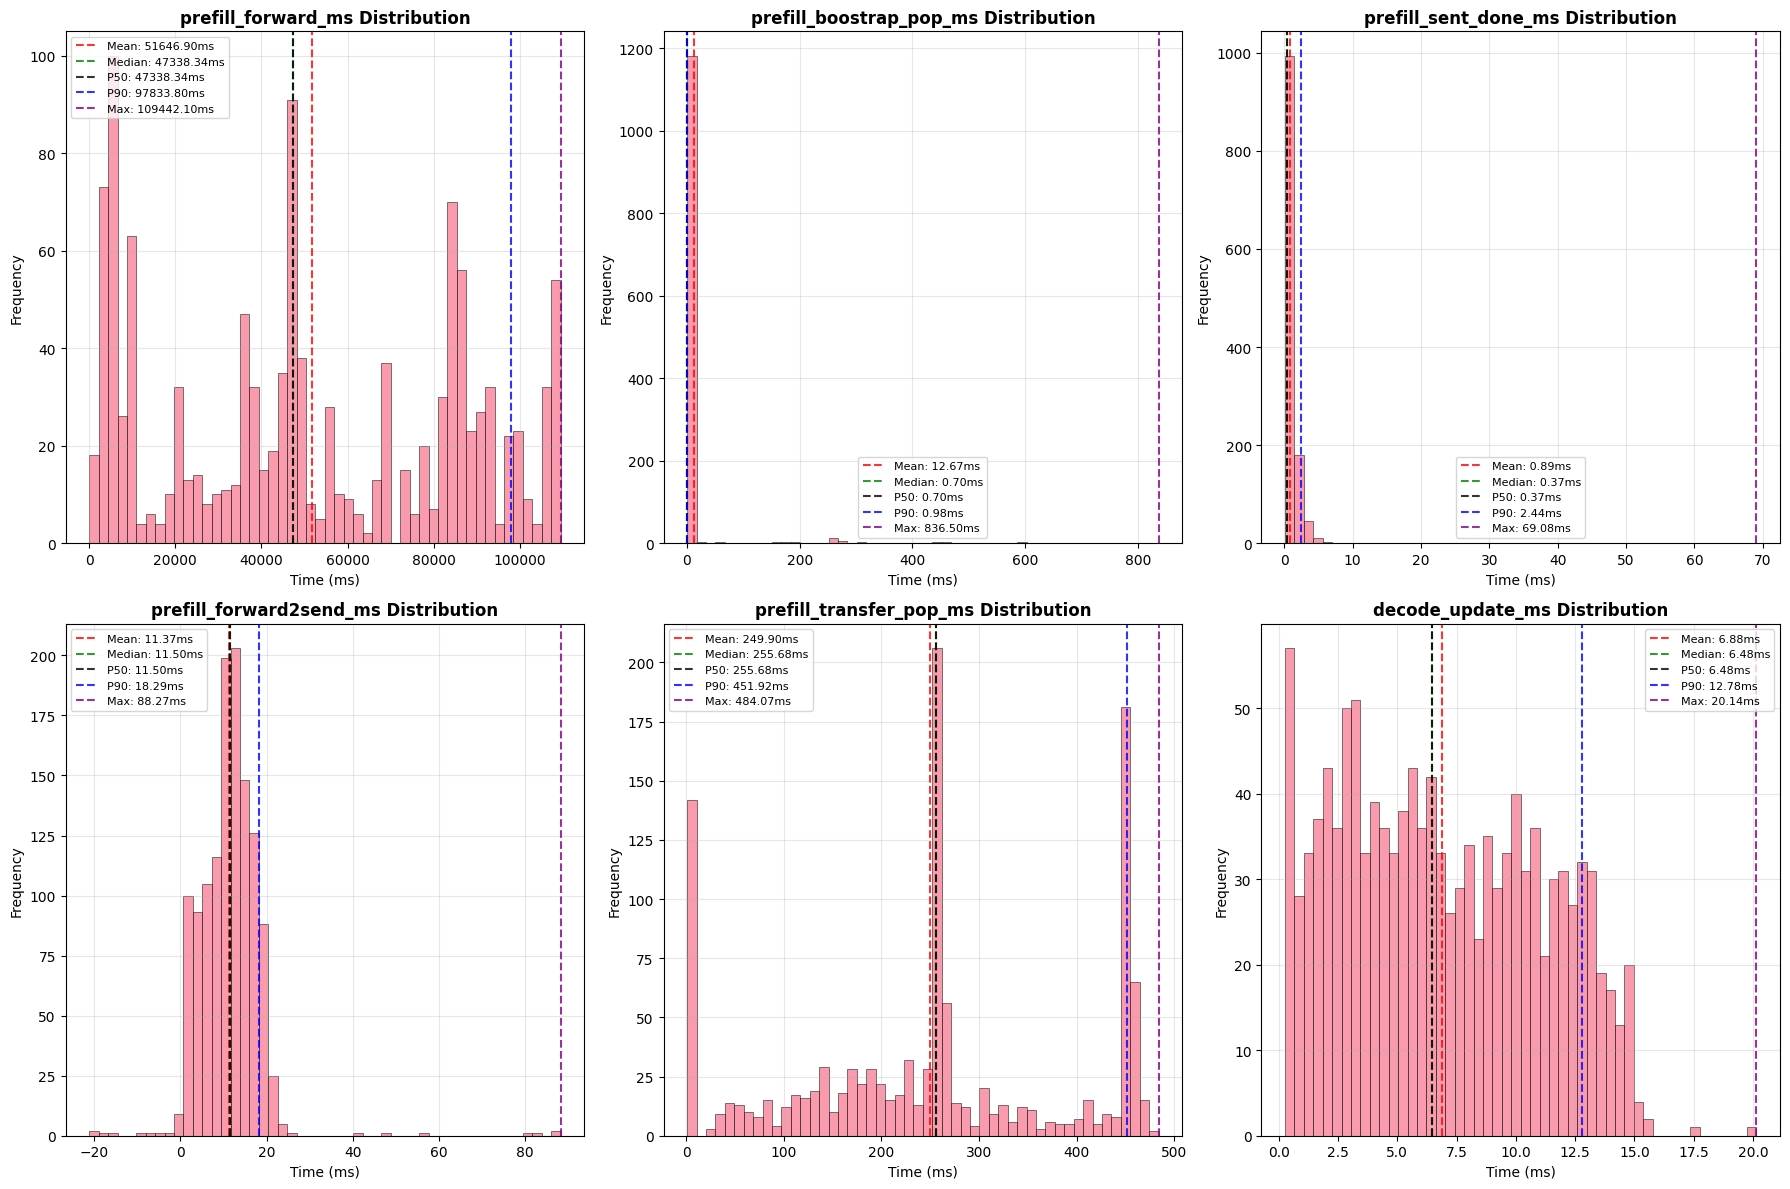

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图样式
plt.style.use('default')
sns.set_palette("husl")

# 要绘制的列
columns_to_plot = summary_df.columns.tolist()[1:]

# 创建子图
fig, axes = plt.subplots(2, len(columns_to_plot)//2, figsize=(18, 12))
axes = axes.flatten()

# 为每个列绘制直方图
for i, col in enumerate(columns_to_plot):
    if col in summary_df.columns:
        # 过滤掉NaN值
        data = summary_df[col].dropna()
        
        # 绘制直方图
        axes[i].hist(data, bins=50, alpha=0.7, edgecolor='black', linewidth=0.5)
        axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Time (ms)', fontsize=10)
        axes[i].set_ylabel('Frequency', fontsize=10)
        axes[i].grid(True, alpha=0.3)
        
        # 添加统计信息
        mean_val = data.mean()
        median_val = data.median()
        axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.2f}ms')
        axes[i].axvline(median_val, color='green', linestyle='--', alpha=0.8, label=f'Median: {median_val:.2f}ms')
        axes[i].axvline(data.quantile(0.5), color='black', linestyle='--', alpha=0.8, label=f'P50: {data.quantile(0.5):.2f}ms')
        axes[i].axvline(data.quantile(0.9), color='blue', linestyle='--', alpha=0.8, label=f'P90: {data.quantile(0.9):.2f}ms')
        axes[i].axvline(data.max(), color='purple', linestyle='--', alpha=0.8, label=f'Max: {data.max():.2f}ms')
        axes[i].legend(fontsize=8)
        
        print(f"{col}: Mean={mean_val:.2f}ms, Median={median_val:.2f}ms, Std={data.std():.2f}ms")

plt.tight_layout()
plt.show()